In [63]:
import sys
from pathlib import Path

# Add project root so we can import from the cityscape_seg package
sys.path.insert(0, str(Path.cwd().parent))

In [64]:
import glob
import os
import random

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from PIL import Image
from skimage.segmentation import find_boundaries
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from tqdm.notebook import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [65]:
# ── Configuration ──
DATA_ROOT = "../data/small_data"
IMG_HEIGHT, IMG_WIDTH = 256, 512
BATCH_SIZE = 10
NUM_CLASSES = 8
NUM_EPOCHS = 15
LR = 1e-4
FOCAL_GAMMA = 2
NUM_TRAIN = 1600  # use a small subset for fast iteration
NUM_VAL = 400
AUGMENT_TRAIN = False  # False to use val_transform on train set (no augmentation)
USE_CLASS_WEIGHTS = False  # False to disable inverse-frequency class weighting
OVERSAMPLE_CLASSES = [1, 2, 4]  # sidewalk, human, traffic object ([] to disable)
# OVERSAMPLE_CLASSES = []
OVERSAMPLE_BOOST = 3.0  # images with these classes are sampled N× more often

CLASS_NAMES = [
    "road/drivable",  # 0
    "sidewalk",  # 1
    "human",  # 2
    "vehicle",  # 3
    "traffic object",  # 4
    "nature",  # 5  (vegetation, terrain, sky)
    "construction",  # 6  (building, wall, fence, guard rail, bridge, tunnel)
    "background",  # 7  (void classes)
]

CLASS_COLORS = [
    (128, 64, 128),  # road – purple
    (244, 35, 232),  # sidewalk – pink
    (220, 20, 60),  # human – crimson
    (0, 0, 142),  # vehicle – dark blue
    (250, 170, 30),  # traffic object – orange
    (107, 142, 35),  # nature – olive green
    (70, 70, 70),  # construction – dark gray
    (0, 0, 0),  # background – black
]

In [66]:
# ── Cityscapes label-ID → 6-class remapping ──
# Cityscapes labelIds: https://github.com/mcordts/cityscapesScripts
# 0-6: void/ego/rectification/out-of-roi/static/dynamic/ground
# 7 road, 8 sidewalk, 9 parking, 10 rail track
# 11 building, 12 wall, 13 fence, 14 guard rail, 15 bridge, 16 tunnel
# 17 pole, 18 polegroup, 19 traffic light, 20 traffic sign
# 21 vegetation, 22 terrain, 23 sky
# 24 person, 25 rider
# 26 car, 27 truck, 28 bus, 29 caravan, 30 trailer, 31 train, 32 motorcycle, 33 bicycle
# 255 / -1: license plate (ignored)

LABEL_REMAP = np.full(256, 7, dtype=np.uint8)  # default → background (void)

# Class 0: road / drivable area
for lid in [7, 9, 10]:
    LABEL_REMAP[lid] = 0

# Class 1: sidewalk
LABEL_REMAP[8] = 1

# Class 2: human
for lid in [24, 25]:
    LABEL_REMAP[lid] = 2

# Class 3: vehicle
for lid in [26, 27, 28, 29, 30, 31, 32, 33]:
    LABEL_REMAP[lid] = 3

# Class 4: traffic object
for lid in [17, 18, 19, 20]:
    LABEL_REMAP[lid] = 4

# Class 5: nature (vegetation, terrain, sky)
for lid in [21, 22, 23]:
    LABEL_REMAP[lid] = 5

# Class 6: construction (building, wall, fence, guard rail, bridge, tunnel)
for lid in [11, 12, 13, 14, 15, 16]:
    LABEL_REMAP[lid] = 6

# Class 7: background (everything else — void classes default to 7)

print("Remap table (non-background entries):")
for i in range(34):
    if LABEL_REMAP[i] != 7:
        print(f"  labelId {i:>2d} → class {LABEL_REMAP[i]} ({CLASS_NAMES[LABEL_REMAP[i]]})")

Remap table (non-background entries):
  labelId  7 → class 0 (road/drivable)
  labelId  8 → class 1 (sidewalk)
  labelId  9 → class 0 (road/drivable)
  labelId 10 → class 0 (road/drivable)
  labelId 11 → class 6 (construction)
  labelId 12 → class 6 (construction)
  labelId 13 → class 6 (construction)
  labelId 14 → class 6 (construction)
  labelId 15 → class 6 (construction)
  labelId 16 → class 6 (construction)
  labelId 17 → class 4 (traffic object)
  labelId 18 → class 4 (traffic object)
  labelId 19 → class 4 (traffic object)
  labelId 20 → class 4 (traffic object)
  labelId 21 → class 5 (nature)
  labelId 22 → class 5 (nature)
  labelId 23 → class 5 (nature)
  labelId 24 → class 2 (human)
  labelId 25 → class 2 (human)
  labelId 26 → class 3 (vehicle)
  labelId 27 → class 3 (vehicle)
  labelId 28 → class 3 (vehicle)
  labelId 29 → class 3 (vehicle)
  labelId 30 → class 3 (vehicle)
  labelId 31 → class 3 (vehicle)
  labelId 32 → class 3 (vehicle)
  labelId 33 → class 3 (vehicle)


In [67]:
# ── Paired image-label augmentation transforms ──
# Spatial transforms are applied identically to both image and label.
# Photometric transforms (ColorJitter) are applied to the image only.
# Source: adapted from https://github.com/pytorch/vision/blob/master/references/segmentation/transforms.py


class PairedCompose:
    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, image, target):
        for t in self.transforms:
            image, target = t(image, target)
        return image, target


class PairedRandomHorizontalFlip:
    def __init__(self, p=0.5):
        self.p = p

    def __call__(self, image, target):
        if random.random() < self.p:
            image = TF.hflip(image)
            target = TF.hflip(target)
        return image, target


class PairedColorJitter:
    """Applies color jitter to the image only (labels are unchanged)."""

    def __init__(self, brightness=0, contrast=0, saturation=0, hue=0):
        self.jitter = T.ColorJitter(brightness, contrast, saturation, hue)

    def __call__(self, image, target):
        return self.jitter(image), target


class PairedRandomResizedCrop:
    """Random crop + resize back to target size (same crop for both)."""

    def __init__(self, size, scale=(0.5, 1.0), ratio=(0.75, 1.33)):
        self.size = size
        self.scale = scale
        self.ratio = ratio

    def __call__(self, image, target):
        i, j, h, w = T.RandomResizedCrop.get_params(image, self.scale, self.ratio)
        image = TF.resized_crop(
            image, i, j, h, w, self.size, interpolation=TF.InterpolationMode.BILINEAR
        )
        target = TF.resized_crop(
            target, i, j, h, w, self.size, interpolation=TF.InterpolationMode.NEAREST
        )
        return image, target


class PairedToTensorAndNormalize:
    """Convert PIL image to tensor + ImageNet-normalize; convert label to numpy."""

    def __init__(self, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
        self.normalize = T.Normalize(mean=mean, std=std)

    def __call__(self, image, target):
        image = self.normalize(TF.to_tensor(image))
        target = np.array(target, dtype=np.uint8)
        return image, target


# ── Build train / val transform pipelines ──
train_transform = PairedCompose(
    [
        PairedRandomHorizontalFlip(p=0.5),
        PairedColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
        PairedRandomResizedCrop(size=(IMG_HEIGHT, IMG_WIDTH), scale=(0.5, 1.0)),
        PairedToTensorAndNormalize(),
    ]
)

val_transform = PairedCompose(
    [
        PairedToTensorAndNormalize(),
    ]
)

In [68]:
# ── Dataset (preloaded PIL images, augmentation applied per-access) ──
class CityscapesSegDataset(Dataset):
    """Loads Cityscapes images + labels into memory as resized PIL images.

    Augmentation transforms are applied lazily in __getitem__ so that each
    epoch sees different random variations of the training data.

    If max_samples is set, only that many randomly chosen pairs are loaded
    (controlled by seed for reproducibility), saving both time and memory.
    """

    def __init__(
        self,
        root_dir,
        split="train",
        img_size=(IMG_HEIGHT, IMG_WIDTH),
        transform=None,
        max_samples=None,
        seed=42,
    ):
        split_dir = os.path.join(root_dir, split)
        self.transform = transform
        self.img_size = img_size

        image_paths = sorted(glob.glob(os.path.join(split_dir, "*_leftImg8bit.png")))
        label_paths = sorted(glob.glob(os.path.join(split_dir, "*_labelIds.png")))
        assert len(image_paths) == len(label_paths), (
            f"Mismatch: {len(image_paths)} images vs {len(label_paths)} labels"
        )

        pairs = list(zip(image_paths, label_paths))
        if max_samples is not None and max_samples < len(pairs):
            rng = np.random.default_rng(seed)
            indices = rng.choice(len(pairs), size=max_samples, replace=False)
            pairs = [pairs[i] for i in sorted(indices)]

        self.images, self.labels = [], []
        for ip, lp in tqdm(pairs, desc=f"Loading [{split}]", unit="img"):
            img = Image.open(ip).convert("RGB")
            lbl = Image.open(lp)

            img = TF.resize(img, img_size, interpolation=TF.InterpolationMode.BILINEAR)
            lbl = TF.resize(lbl, img_size, interpolation=TF.InterpolationMode.NEAREST)

            self.images.append(img)
            self.labels.append(lbl)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img, lbl = self.images[idx], self.labels[idx]

        if self.transform is not None:
            img, lbl = self.transform(img, lbl)

        # img is now a normalized [3, H, W] tensor; lbl is a uint8 numpy array
        lbl_np = (
            LABEL_REMAP[lbl]
            if isinstance(lbl, np.ndarray)
            else LABEL_REMAP[np.array(lbl, dtype=np.uint8)]
        )
        lbl_t = torch.from_numpy(lbl_np).long()

        boundary = find_boundaries(lbl_np, mode="outer").astype(np.uint8)
        boundary += 1  # 1 = interior, 2 = boundary
        mask = torch.from_numpy(boundary).float()

        return img, lbl_t, mask

In [69]:
# ── Datasets (only load the samples we need) ──
train_tf = train_transform if AUGMENT_TRAIN else val_transform
print(f"Train augmentation: {'enabled' if AUGMENT_TRAIN else 'disabled'}")

train_ds = CityscapesSegDataset(
    DATA_ROOT, "train", transform=train_tf, max_samples=NUM_TRAIN, seed=42
)
val_ds = CityscapesSegDataset(
    DATA_ROOT, "valid", transform=val_transform, max_samples=NUM_VAL, seed=42
)

Train augmentation: disabled


Loading [train]:   0%|          | 0/1600 [00:00<?, ?img/s]

Loading [valid]:   0%|          | 0/400 [00:00<?, ?img/s]

In [70]:
# ── Oversampling (optional) ──
if OVERSAMPLE_CLASSES:
    sample_weights = torch.ones(len(train_ds))
    n_boosted = 0
    for i in range(len(train_ds)):
        _, lbl, _ = train_ds[i]
        if any((lbl == c).any() for c in OVERSAMPLE_CLASSES):
            sample_weights[i] = OVERSAMPLE_BOOST
            n_boosted += 1

    sampler = WeightedRandomSampler(sample_weights, num_samples=len(train_ds), replacement=True)
    boosted_names = [CLASS_NAMES[c] for c in OVERSAMPLE_CLASSES]
    print(
        f"Oversampling: {n_boosted}/{len(train_ds)} images boosted {OVERSAMPLE_BOOST}× "
        f"(contain {', '.join(boosted_names)})"
    )
else:
    sampler = None
    print("Oversampling: disabled")

# ── DataLoaders ──
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=(sampler is None),
    sampler=sampler,
    num_workers=0,
    pin_memory=True,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True
)

print(f"Train: {len(train_ds)} samples  ({len(train_loader)} batches)")
print(f"Val:   {len(val_ds)} samples  ({len(val_loader)} batches)")

Oversampling: 1600/1600 images boosted 3.0× (contain sidewalk, human, traffic object)
Train: 1600 samples  (160 batches)
Val:   400 samples  (40 batches)


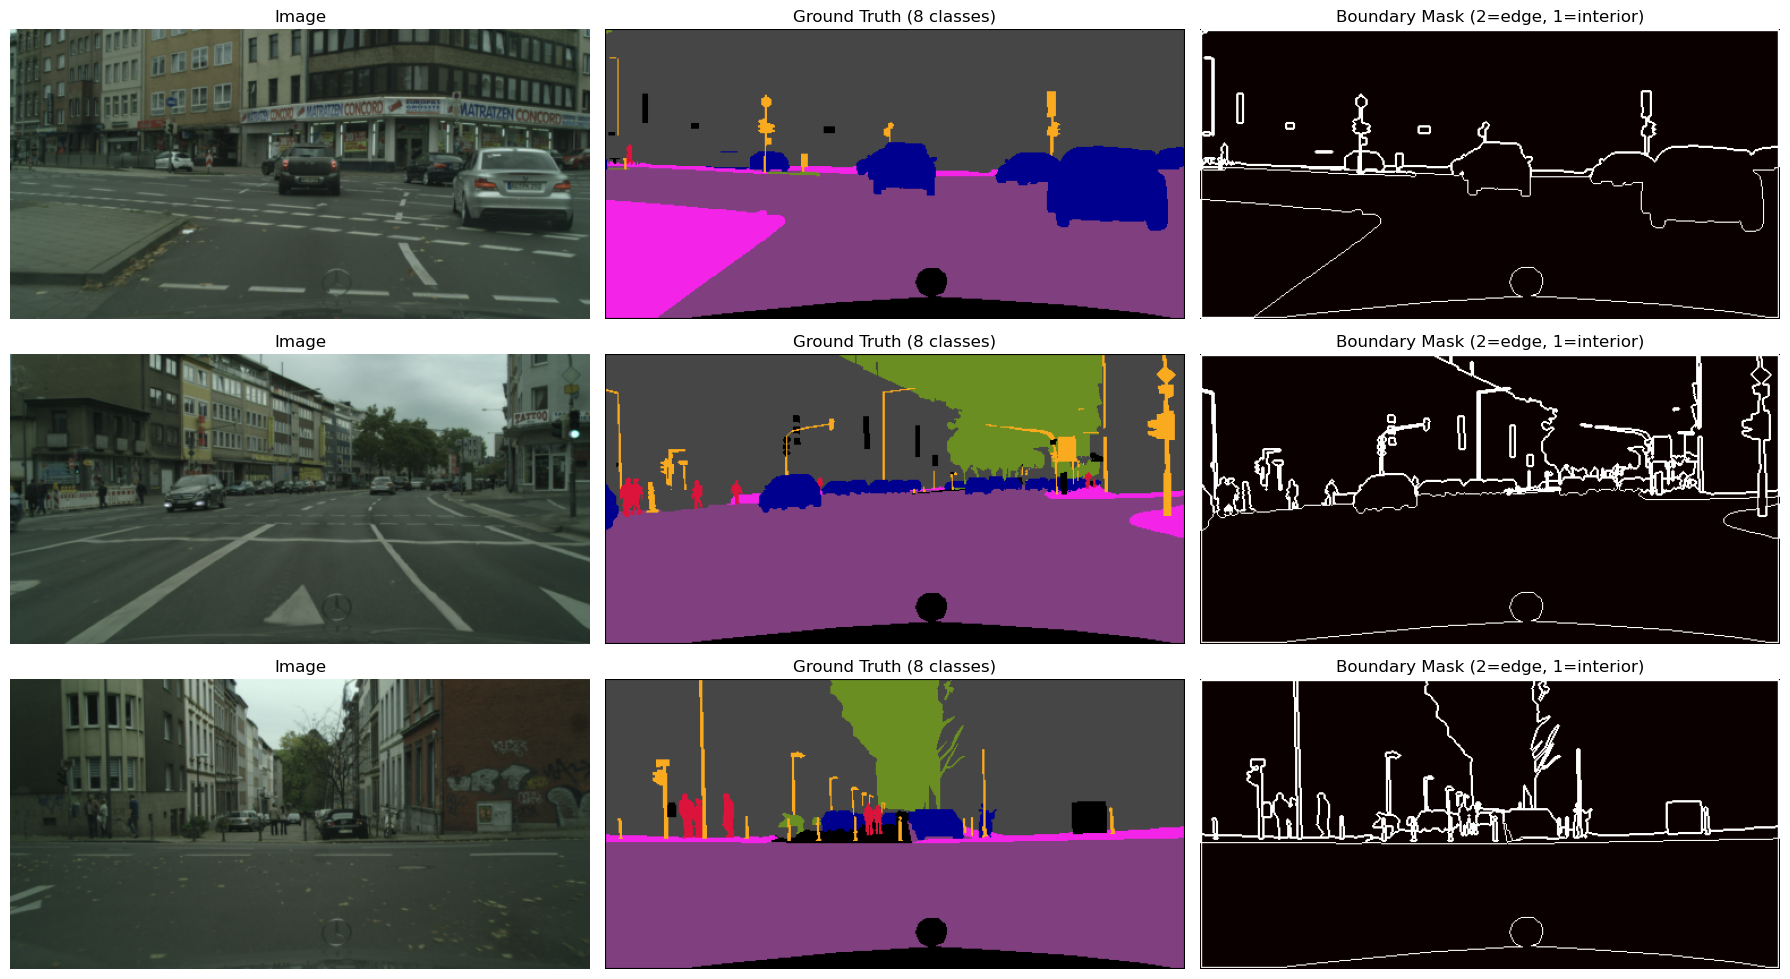

In [71]:
# ── Visualize a few training samples ──
def label_to_color(lbl_np):
    """Convert a HxW label map to an HxWx3 RGB image."""
    h, w = lbl_np.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for cls_id, color in enumerate(CLASS_COLORS):
        rgb[lbl_np == cls_id] = color
    return rgb


inv_normalize = T.Normalize(
    mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
    std=[1 / 0.229, 1 / 0.224, 1 / 0.225],
)

fig, axes = plt.subplots(3, 3, figsize=(18, 10))
for i in range(3):
    img, lbl, mask = train_ds[i]
    img_vis = inv_normalize(img).permute(1, 2, 0).clamp(0, 1).numpy()
    lbl_vis = label_to_color(lbl.numpy())
    mask_vis = mask.numpy()

    axes[i, 0].imshow(img_vis)
    axes[i, 0].set_title("Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(lbl_vis)
    axes[i, 1].set_title(f"Ground Truth ({NUM_CLASSES} classes)")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(mask_vis, cmap="hot", vmin=1, vmax=2)
    axes[i, 2].set_title("Boundary Mask (2=edge, 1=interior)")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

Class pixel distribution:
  road/drivable         pixels:   69963920  (33.4%)
  sidewalk              pixels:   11202186  (5.3%)
  human                 pixels:    2406448  (1.1%)
  vehicle               pixels:   15899328  (7.6%)
  traffic object        pixels:    3651710  (1.7%)
  nature                pixels:   39407968  (18.8%)
  construction          pixels:   46232800  (22.0%)
  background            pixels:   20950820  (10.0%)


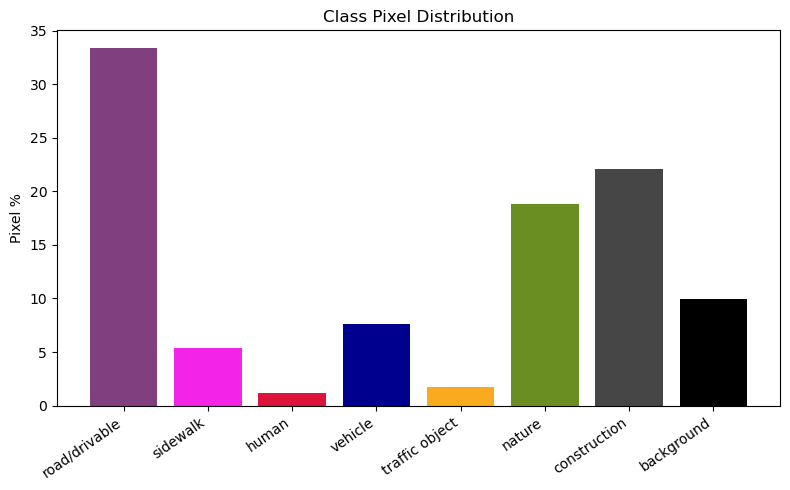


Focal Loss  |  gamma=2  |  class_weights=disabled


In [72]:
# ── Class weights + Focal Loss ──

# Compute inverse-frequency weights from the training subset
pixel_counts = torch.zeros(NUM_CLASSES)
for _, lbl, _ in train_loader:
    for c in range(NUM_CLASSES):
        pixel_counts[c] += (lbl == c).sum()

freq = pixel_counts / pixel_counts.sum()
inv_freq = 1.0 / (freq + 1e-6)

if USE_CLASS_WEIGHTS:
    # Dampened weights (sqrt of inverse frequency)
    class_weights = (inv_freq.sqrt() / inv_freq.sqrt().sum() * NUM_CLASSES).to(device)
else:
    class_weights = None

print("Class pixel distribution:")
for i, (name, cnt) in enumerate(zip(CLASS_NAMES, pixel_counts)):
    w_str = f"  weight: {class_weights[i]:.3f}" if class_weights is not None else ""
    print(f"  {name:<20s}  pixels: {cnt.item():>10.0f}  ({freq[i] * 100:.1f}%){w_str}")

fig, axes = plt.subplots(
    1, 2 if USE_CLASS_WEIGHTS else 1, figsize=(16 if USE_CLASS_WEIGHTS else 8, 5)
)

colors = [np.array(c) / 255 for c in CLASS_COLORS]
x = range(NUM_CLASSES)

ax1 = axes[0] if USE_CLASS_WEIGHTS else axes
ax1.bar(x, freq.numpy() * 100, color=colors)
ax1.set_xticks(x)
ax1.set_xticklabels(CLASS_NAMES, rotation=35, ha="right")
ax1.set_ylabel("Pixel %")
ax1.set_title("Class Pixel Distribution")

if USE_CLASS_WEIGHTS:
    axes[1].bar(x, class_weights.cpu().numpy(), color=colors)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(CLASS_NAMES, rotation=35, ha="right")
    axes[1].set_ylabel("Weight")
    axes[1].set_title("Dampened Inverse-Frequency Class Weights")

plt.tight_layout()
plt.show()


class FocalLoss(nn.Module):
    """Weighted Focal Loss for multi-class segmentation.

    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    Args:
        alpha:  per-class weights, shape [C]. Balances rare vs frequent classes.
        gamma:  focusing parameter (>=0). Higher values down-weight easy examples more.
                gamma=0 reduces to weighted cross-entropy.
    """

    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.gamma = gamma
        if alpha is not None:
            self.register_buffer("alpha", alpha.clone())
        else:
            self.alpha = None

    def forward(self, logits, targets, mask=None):
        ce = nn.functional.cross_entropy(logits, targets, reduction="none")
        pt = torch.exp(-ce)

        focal = (1.0 - pt) ** self.gamma * ce

        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            focal = alpha_t * focal

        if mask is not None:
            focal = focal * mask

        return focal.mean()


criterion = FocalLoss(alpha=class_weights, gamma=FOCAL_GAMMA)
w_info = class_weights.cpu().tolist() if class_weights is not None else "disabled"
print(f"\nFocal Loss  |  gamma={criterion.gamma}  |  class_weights={w_info}")

In [73]:
# ── FCN-8s Model (built from scratch) ──
#
# Architecture following Long et al. "Fully Convolutional Networks
# for Semantic Segmentation" (CVPR 2015):
#
#   Encoder : 5 VGG-style blocks (conv-bn-relu pairs + maxpool)
#   Bridge  : two 1x1 conv layers (replace the original FC6/FC7)
#   Decoder : transposed convolutions with FCN-8s skip connections
#             from pool3 and pool4 for fine-grained spatial detail
#
# Input  : (B, 3, 256, 512)
# Output : (B, NUM_CLASSES, 256, 512)  – logits, same size as input


class ConvBlock(nn.Module):
    """N consecutive (Conv3x3 → BN → ReLU) layers."""

    def __init__(self, in_ch, out_ch, n_convs=2):
        super().__init__()
        layers = []
        for i in range(n_convs):
            layers.append(nn.Conv2d(in_ch if i == 0 else out_ch, out_ch, 3, padding=1))
            layers.append(nn.BatchNorm2d(out_ch))
            layers.append(nn.ReLU(inplace=True))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class FCN8s(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # ── Encoder ──
        self.enc1 = ConvBlock(3, 64, n_convs=2)  # /1
        self.enc2 = ConvBlock(64, 128, n_convs=2)  # /2
        self.enc3 = ConvBlock(128, 256, n_convs=3)  # /4
        self.enc4 = ConvBlock(256, 512, n_convs=3)  # /8
        self.enc5 = ConvBlock(512, 512, n_convs=3)  # /16

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # ── Bridge (replaces FC6 / FC7) ──
        self.bridge = nn.Sequential(
            nn.Conv2d(512, 1024, 1),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.5),
            nn.Conv2d(1024, 1024, 1),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.5),
        )

        # ── Decoder (FCN-8s) ──
        # score from bridge  → num_classes channels at /32
        self.score_bridge = nn.Conv2d(1024, num_classes, 1)

        # upsample /32 → /16,  fuse with pool4 skip
        self.up_bridge = nn.ConvTranspose2d(num_classes, num_classes, 4, stride=2, padding=1)
        self.score_pool4 = nn.Conv2d(512, num_classes, 1)

        # upsample /16 → /8,  fuse with pool3 skip
        self.up_pool4 = nn.ConvTranspose2d(num_classes, num_classes, 4, stride=2, padding=1)
        self.score_pool3 = nn.Conv2d(256, num_classes, 1)

        # upsample /8 → /1  (8× bilinear-initialised)
        self.up_final = nn.ConvTranspose2d(num_classes, num_classes, 16, stride=8, padding=4)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.ConvTranspose2d):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        # ── Encoder ──
        e1 = self.enc1(x)  # (B,  64, H,   W)
        p1 = self.pool(e1)  # (B,  64, H/2, W/2)

        e2 = self.enc2(p1)  # (B, 128, H/2, W/2)
        p2 = self.pool(e2)  # (B, 128, H/4, W/4)

        e3 = self.enc3(p2)  # (B, 256, H/4, W/4)
        p3 = self.pool(e3)  # (B, 256, H/8, W/8)     ← pool3 skip

        e4 = self.enc4(p3)  # (B, 512, H/8, W/8)
        p4 = self.pool(e4)  # (B, 512, H/16, W/16)   ← pool4 skip

        e5 = self.enc5(p4)  # (B, 512, H/16, W/16)
        p5 = self.pool(e5)  # (B, 512, H/32, W/32)

        # ── Bridge ──
        b = self.bridge(p5)  # (B, 1024, H/32, W/32)

        # ── Decoder with skip connections ──
        s_bridge = self.score_bridge(b)  # (B, C, H/32, W/32)
        up1 = self.up_bridge(s_bridge)  # (B, C, H/16, W/16)
        s_pool4 = self.score_pool4(p4)  # (B, C, H/16, W/16)
        fuse1 = up1 + s_pool4

        up2 = self.up_pool4(fuse1)  # (B, C, H/8, W/8)
        s_pool3 = self.score_pool3(p3)  # (B, C, H/8, W/8)
        fuse2 = up2 + s_pool3

        out = self.up_final(fuse2)  # (B, C, H, W)
        return out


class UNet(nn.Module):
    """U-Net for semantic segmentation (Ronneberger et al., 2015).

    Symmetric encoder-decoder with skip connections via concatenation.
    Uses the same ConvBlock building block as FCN8s above.
    """

    def __init__(self, num_classes, base_ch=32):
        super().__init__()

        # ── Encoder ──
        self.enc1 = ConvBlock(3, base_ch)
        self.enc2 = ConvBlock(base_ch, base_ch * 2)
        self.enc3 = ConvBlock(base_ch * 2, base_ch * 4)
        self.enc4 = ConvBlock(base_ch * 4, base_ch * 8)

        self.pool = nn.MaxPool2d(2)

        # ── Bottleneck ──
        self.bottleneck = ConvBlock(base_ch * 8, base_ch * 16)

        # ── Decoder ──
        self.up4 = nn.ConvTranspose2d(base_ch * 16, base_ch * 8, 2, stride=2)
        self.dec4 = ConvBlock(base_ch * 16, base_ch * 8)

        self.up3 = nn.ConvTranspose2d(base_ch * 8, base_ch * 4, 2, stride=2)
        self.dec3 = ConvBlock(base_ch * 8, base_ch * 4)

        self.up2 = nn.ConvTranspose2d(base_ch * 4, base_ch * 2, 2, stride=2)
        self.dec2 = ConvBlock(base_ch * 4, base_ch * 2)

        self.up1 = nn.ConvTranspose2d(base_ch * 2, base_ch, 2, stride=2)
        self.dec1 = ConvBlock(base_ch * 2, base_ch)

        self.head = nn.Conv2d(base_ch, num_classes, 1)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(self.pool(e4))

        # Decoder with skip concatenation
        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.head(d1)


class ASPP(nn.Module):
    """Atrous Spatial Pyramid Pooling (Chen et al., 2017).

    Parallel branches with different dilation rates capture multi-scale context.
    """

    def __init__(self, in_ch, out_ch=256, rates=(6, 12, 18)):
        super().__init__()
        modules = [
            nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            )
        ]
        for rate in rates:
            modules.append(
                nn.Sequential(
                    nn.Conv2d(in_ch, out_ch, 3, padding=rate, dilation=rate, bias=False),
                    nn.BatchNorm2d(out_ch),
                    nn.ReLU(inplace=True),
                )
            )
        # Image-level features (global average pooling; no BN -- spatial size is 1x1)
        modules.append(
            nn.Sequential(
                nn.AdaptiveAvgPool2d(1),
                nn.Conv2d(in_ch, out_ch, 1),
                nn.ReLU(inplace=True),
            )
        )
        self.branches = nn.ModuleList(modules)
        self.project = nn.Sequential(
            nn.Conv2d(out_ch * (len(rates) + 2), out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
        )

    def forward(self, x):
        results = []
        for branch in self.branches[:-1]:
            results.append(branch(x))
        # Image-level: pool → conv → upsample back to spatial size
        img_feat = self.branches[-1](x)
        img_feat = nn.functional.interpolate(
            img_feat, size=x.shape[2:], mode="bilinear", align_corners=False
        )
        results.append(img_feat)
        return self.project(torch.cat(results, dim=1))


class DeepLabV3Plus(nn.Module):
    """DeepLabV3+ (Chen et al., 2018) built from scratch.

    Encoder : 4 VGG-style stages (ConvBlock + MaxPool), output stride 16
    ASPP    : multi-scale context at the encoder output
    Decoder : low-level skip from stage 1 (stride 4), refine + upsample
    """

    def __init__(self, num_classes, base_ch=32):
        super().__init__()
        # ── Encoder (output stride 16) ──
        self.enc1 = ConvBlock(3, base_ch, n_convs=2)  # stride 1
        self.enc2 = ConvBlock(base_ch, base_ch * 2, n_convs=2)  # stride 2
        self.enc3 = ConvBlock(base_ch * 2, base_ch * 4, n_convs=3)  # stride 4
        self.enc4 = ConvBlock(base_ch * 4, base_ch * 8, n_convs=3)  # stride 8
        self.pool = nn.MaxPool2d(2)

        # ── ASPP on encoder output (stride 16) ──
        aspp_out_ch = 256
        self.aspp = ASPP(base_ch * 8, out_ch=aspp_out_ch)

        # ── Decoder ──
        low_level_ch = base_ch  # from enc1, before pool → stride 2 after pool
        self.low_level_proj = nn.Sequential(
            nn.Conv2d(low_level_ch, 48, 1, bias=False),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True),
        )
        self.refine = nn.Sequential(
            nn.Conv2d(aspp_out_ch + 48, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
        )
        self.head = nn.Conv2d(256, num_classes, 1)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        h, w = x.shape[2:]

        # Encoder
        e1 = self.enc1(x)  # (B, base_ch, H, W)
        e2 = self.enc2(self.pool(e1))  # (B, base_ch*2, H/2, W/2)
        e3 = self.enc3(self.pool(e2))  # (B, base_ch*4, H/4, W/4)
        e4 = self.enc4(self.pool(e3))  # (B, base_ch*8, H/8, W/8)
        deep = self.pool(e4)  # (B, base_ch*8, H/16, W/16)

        # ASPP
        aspp_out = self.aspp(deep)  # (B, 256, H/16, W/16)

        # Decoder: upsample ASPP 4× → concat with projected low-level (enc2 at H/2)
        # Low-level features: use enc2 output (stride 2) for richer spatial detail
        # but project enc1 pooled output, which matches stride 2
        low_level = self.low_level_proj(self.pool(e1))  # (B, 48, H/2, W/2)

        aspp_up = nn.functional.interpolate(
            aspp_out, size=low_level.shape[2:], mode="bilinear", align_corners=False
        )
        fused = torch.cat([aspp_up, low_level], dim=1)  # (B, 256+48, H/2, W/2)
        refined = self.refine(fused)  # (B, 256, H/2, W/2)

        out = self.head(refined)  # (B, num_classes, H/2, W/2)
        out = nn.functional.interpolate(out, size=(h, w), mode="bilinear", align_corners=False)
        return out


# ── Select model ──
MODEL_NAME = "deeplabv3plus"  # "fcn8s", "unet", or "deeplabv3plus"

MODELS = {"fcn8s": FCN8s, "unet": UNet, "deeplabv3plus": DeepLabV3Plus}
model = MODELS[MODEL_NAME](NUM_CLASSES).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"{MODEL_NAME}  |  Total params: {total_params:,}  |  Trainable: {trainable_params:,}")

# Verify output shape
with torch.no_grad():
    dummy = torch.randn(1, 3, IMG_HEIGHT, IMG_WIDTH, device=device)
    out = model(dummy)
    print(f"Input: {dummy.shape} → Output: {out.shape}")

deeplabv3plus  |  Total params: 5,438,600  |  Trainable: 5,438,600
Input: torch.Size([1, 3, 256, 512]) → Output: torch.Size([1, 8, 256, 512])


In [74]:
# ── Training loop (with AMP mixed precision) ──
# criterion is defined above (Focal Loss with class weights)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2, min_lr=1e-6
)
scaler = torch.amp.GradScaler("cuda")

train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_loss = float("inf")
best_state = None

epoch_bar = tqdm(range(1, NUM_EPOCHS + 1), desc="Epochs")
for epoch in epoch_bar:
    # ─── Train ───
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    train_bar = tqdm(train_loader, desc=f"  Train {epoch}/{NUM_EPOCHS}", leave=False)
    for imgs, lbls, masks in train_bar:
        imgs, lbls, masks = imgs.to(device), lbls.to(device), masks.to(device)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda"):
            out = model(imgs)  # [B, C, H, W]
            loss = criterion(out, lbls, masks)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * imgs.size(0)
        preds = out.argmax(dim=1)
        correct += (preds == lbls).sum().item()
        total += lbls.numel()
        train_bar.set_postfix(loss=f"{loss.item():.4f}")

    train_losses.append(running_loss / len(train_ds))
    train_accs.append(correct / total)

    # ─── Validate ───
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    val_bar = tqdm(val_loader, desc=f"  Val   {epoch}/{NUM_EPOCHS}", leave=False)
    with torch.no_grad(), torch.amp.autocast("cuda"):
        for imgs, lbls, masks in val_bar:
            imgs, lbls, masks = imgs.to(device), lbls.to(device), masks.to(device)
            out = model(imgs)
            loss = criterion(out, lbls, masks)

            running_loss += loss.item() * imgs.size(0)
            preds = out.argmax(dim=1)
            correct += (preds == lbls).sum().item()
            total += lbls.numel()

    val_losses.append(running_loss / len(val_ds))
    val_accs.append(correct / total)

    v_loss = val_losses[-1]
    if v_loss < best_val_loss:
        best_val_loss = v_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    scheduler.step(v_loss)
    lr_now = optimizer.param_groups[0]["lr"]

    epoch_bar.set_postfix(
        t_loss=f"{train_losses[-1]:.4f}",
        t_acc=f"{train_accs[-1]:.4f}",
        v_loss=f"{v_loss:.4f}",
        v_acc=f"{val_accs[-1]:.4f}",
        lr=f"{lr_now:.2e}",
    )

print("\nTraining complete.")
if best_state is not None:
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    print(f"Loaded best checkpoint (val_loss={best_val_loss:.4f}) for evaluation.")

Epochs:   0%|          | 0/15 [00:00<?, ?it/s]

  Train 1/15:   0%|          | 0/160 [00:00<?, ?it/s]

  Val   1/15:   0%|          | 0/40 [00:00<?, ?it/s]

  Train 2/15:   0%|          | 0/160 [00:00<?, ?it/s]

  Val   2/15:   0%|          | 0/40 [00:00<?, ?it/s]

...

  Train 14/15:   0%|          | 0/160 [00:00<?, ?it/s]

  Val   14/15:   0%|          | 0/40 [00:00<?, ?it/s]

  Train 15/15:   0%|          | 0/160 [00:00<?, ?it/s]

  Val   15/15:   0%|          | 0/40 [00:00<?, ?it/s]


Training complete.
Loaded best checkpoint (val_loss=0.3153) for evaluation.


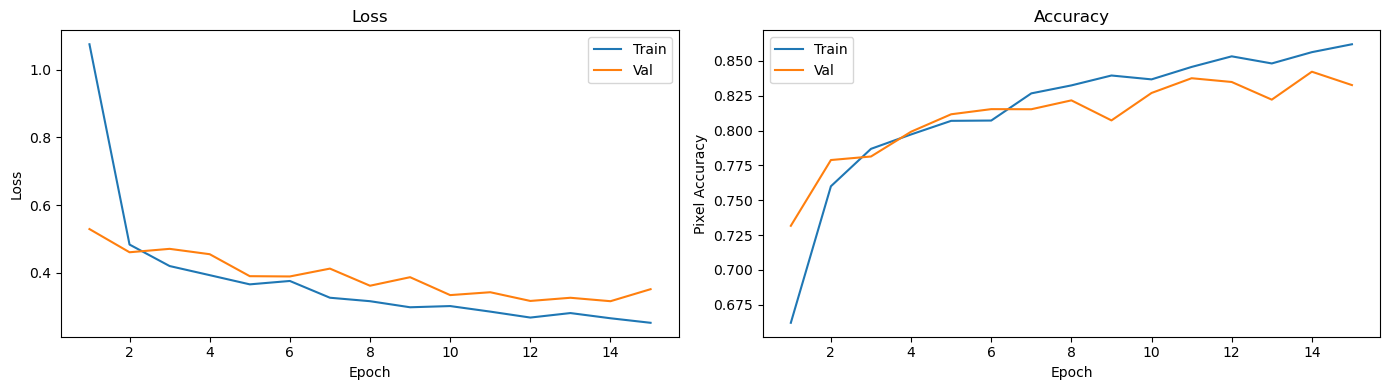

In [75]:
# ── Training curves ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
epochs_range = range(1, NUM_EPOCHS + 1)

ax1.plot(epochs_range, train_losses, label="Train")
ax1.plot(epochs_range, val_losses, label="Val")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss")
ax1.legend()

ax2.plot(epochs_range, train_accs, label="Train")
ax2.plot(epochs_range, val_accs, label="Val")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Pixel Accuracy")
ax2.set_title("Accuracy")
ax2.legend()

plt.tight_layout()
plt.show()

In [76]:
# ── Evaluation: per-class IoU and mIoU ──
def compute_miou(model, loader, num_classes, device):
    """Compute per-class IoU, mean IoU, and confusion matrix over a DataLoader."""
    confusion = torch.zeros(num_classes, num_classes, dtype=torch.long)
    model.eval()
    with torch.no_grad(), torch.amp.autocast("cuda"):
        for imgs, lbls, _ in tqdm(loader, desc="Evaluating", leave=False):
            imgs = imgs.to(device)
            preds = model(imgs).argmax(dim=1).cpu()
            t_flat = lbls.view(-1)
            p_flat = preds.view(-1)
            indices = t_flat * num_classes + p_flat
            confusion += torch.bincount(indices, minlength=num_classes**2).reshape(
                num_classes, num_classes
            )

    ious = []
    for c in range(num_classes):
        tp = confusion[c, c].item()
        fp = confusion[:, c].sum().item() - tp
        fn = confusion[c, :].sum().item() - tp
        denom = tp + fp + fn
        ious.append(tp / denom if denom > 0 else 0.0)
    return ious, confusion


ious, conf_matrix = compute_miou(model, val_loader, NUM_CLASSES, device)
print(f"{'Class':<20s} {'IoU':>8s}")
print("-" * 30)
for name, iou in zip(CLASS_NAMES, ious):
    print(f"{name:<20s} {iou:>8.4f}")
print("-" * 30)
print(f"{'mIoU':<20s} {np.mean(ious):>8.4f}")

Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

Class                     IoU
------------------------------
road/drivable          0.8569
sidewalk               0.4391
human                  0.3333
vehicle                0.6556
traffic object         0.1277
nature                 0.8166
construction           0.7110
background             0.5953
------------------------------
mIoU                   0.5669


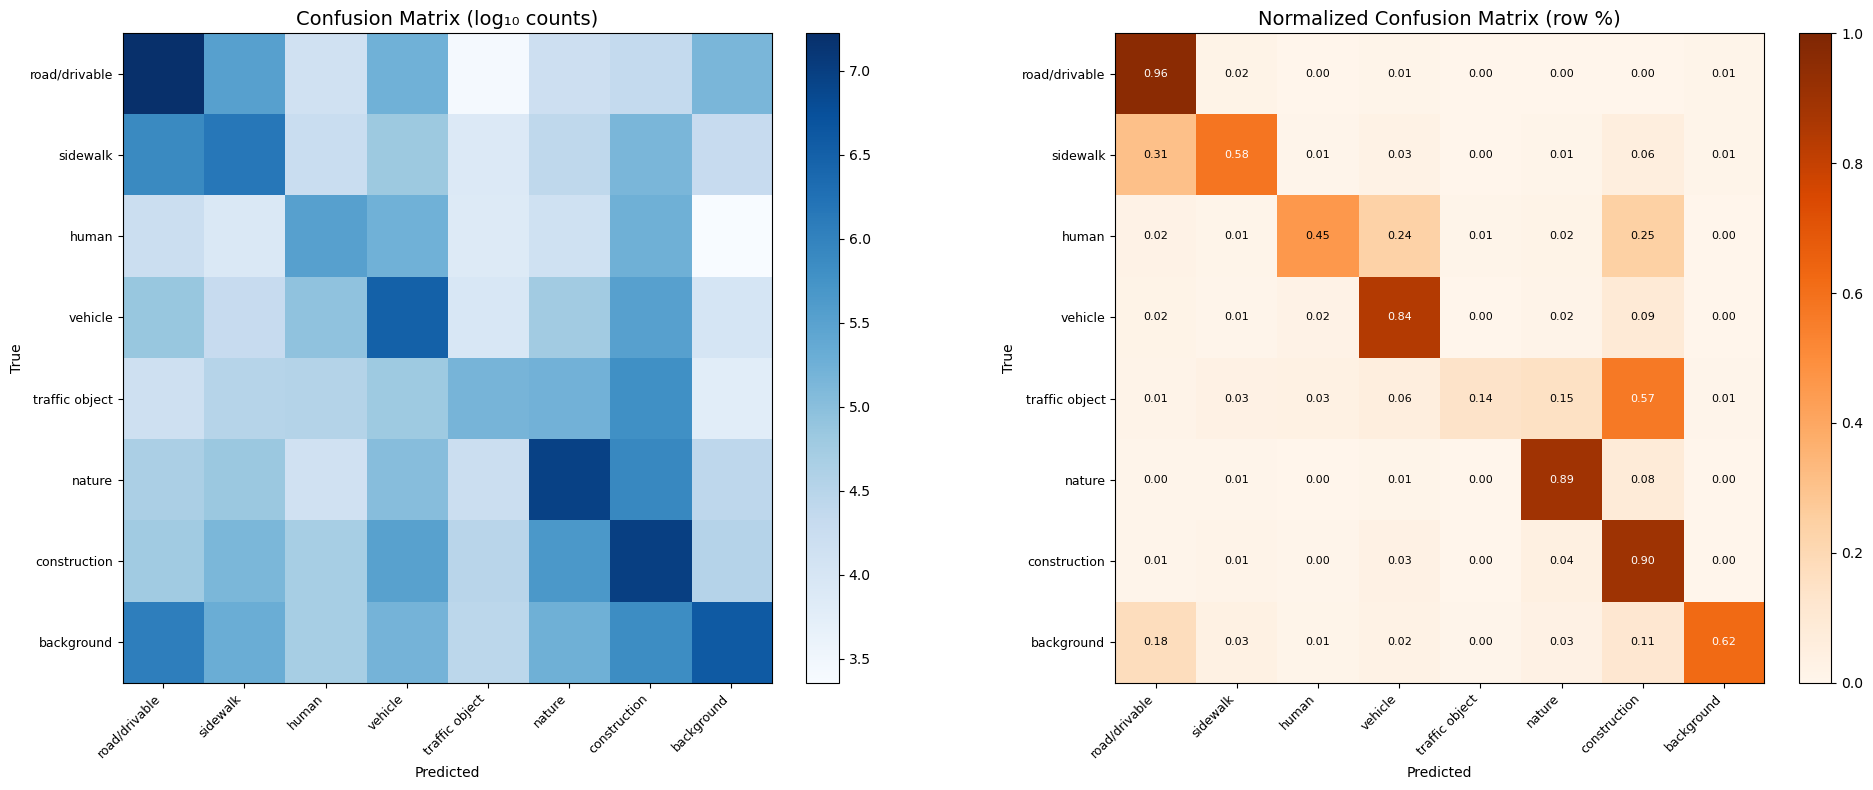

True Class           → Predicted As         Error Rate  Pixel Count
traffic object       → construction             56.90%      619,631
sidewalk             → road/drivable            30.85%      768,438
human                → construction             24.61%      179,163
human                → vehicle                  23.52%      171,269
background           → road/drivable            17.55%    1,109,491
traffic object       → nature                   15.40%      167,753
background           → construction             11.01%      696,138
vehicle              → construction              9.05%      337,404
nature               → construction              8.20%      821,806
traffic object       → vehicle                   5.80%       63,212
sidewalk             → construction              5.69%      141,741
construction         → nature                    4.20%      449,224
traffic object       → human                     3.16%       34,432
background           → sidewalk                 

In [77]:
# ── Confusion Matrix Heatmap ──
cm = conf_matrix.numpy().astype(float)

# row-normalize: each row shows what fraction of that true class was predicted as each class
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, where=row_sums > 0, out=np.zeros_like(cm))

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Left: raw counts (log scale for readability)
cm_log = np.log10(cm + 1)
im0 = axes[0].imshow(cm_log, cmap="Blues")
axes[0].set_title("Confusion Matrix (log₁₀ counts)", fontsize=14)
axes[0].set_xticks(range(NUM_CLASSES))
axes[0].set_yticks(range(NUM_CLASSES))
axes[0].set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=9)
axes[0].set_yticklabels(CLASS_NAMES, fontsize=9)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# Right: row-normalized (% of true class predicted as each class)
im1 = axes[1].imshow(cm_norm, cmap="Oranges", vmin=0, vmax=1)
axes[1].set_title("Normalized Confusion Matrix (row %)", fontsize=14)
axes[1].set_xticks(range(NUM_CLASSES))
axes[1].set_yticks(range(NUM_CLASSES))
axes[1].set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=9)
axes[1].set_yticklabels(CLASS_NAMES, fontsize=9)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        val = cm_norm[i, j]
        color = "white" if val > 0.5 else "black"
        axes[1].text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color=color)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# ── Most Confused Class Pairs ──
# Collect all off-diagonal (true_class → predicted_class) error rates
confusions = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and row_sums[i, 0] > 0:
            confusions.append((CLASS_NAMES[i], CLASS_NAMES[j], cm_norm[i, j], int(cm[i, j])))

confusions.sort(key=lambda x: x[2], reverse=True)

top_k = 15
print(f"{'True Class':<20s} → {'Predicted As':<20s} {'Error Rate':>10s} {'Pixel Count':>12s}")
print("=" * 66)
for true_cls, pred_cls, rate, count in confusions[:top_k]:
    print(f"{true_cls:<20s} → {pred_cls:<20s} {rate:>10.2%} {count:>12,}")

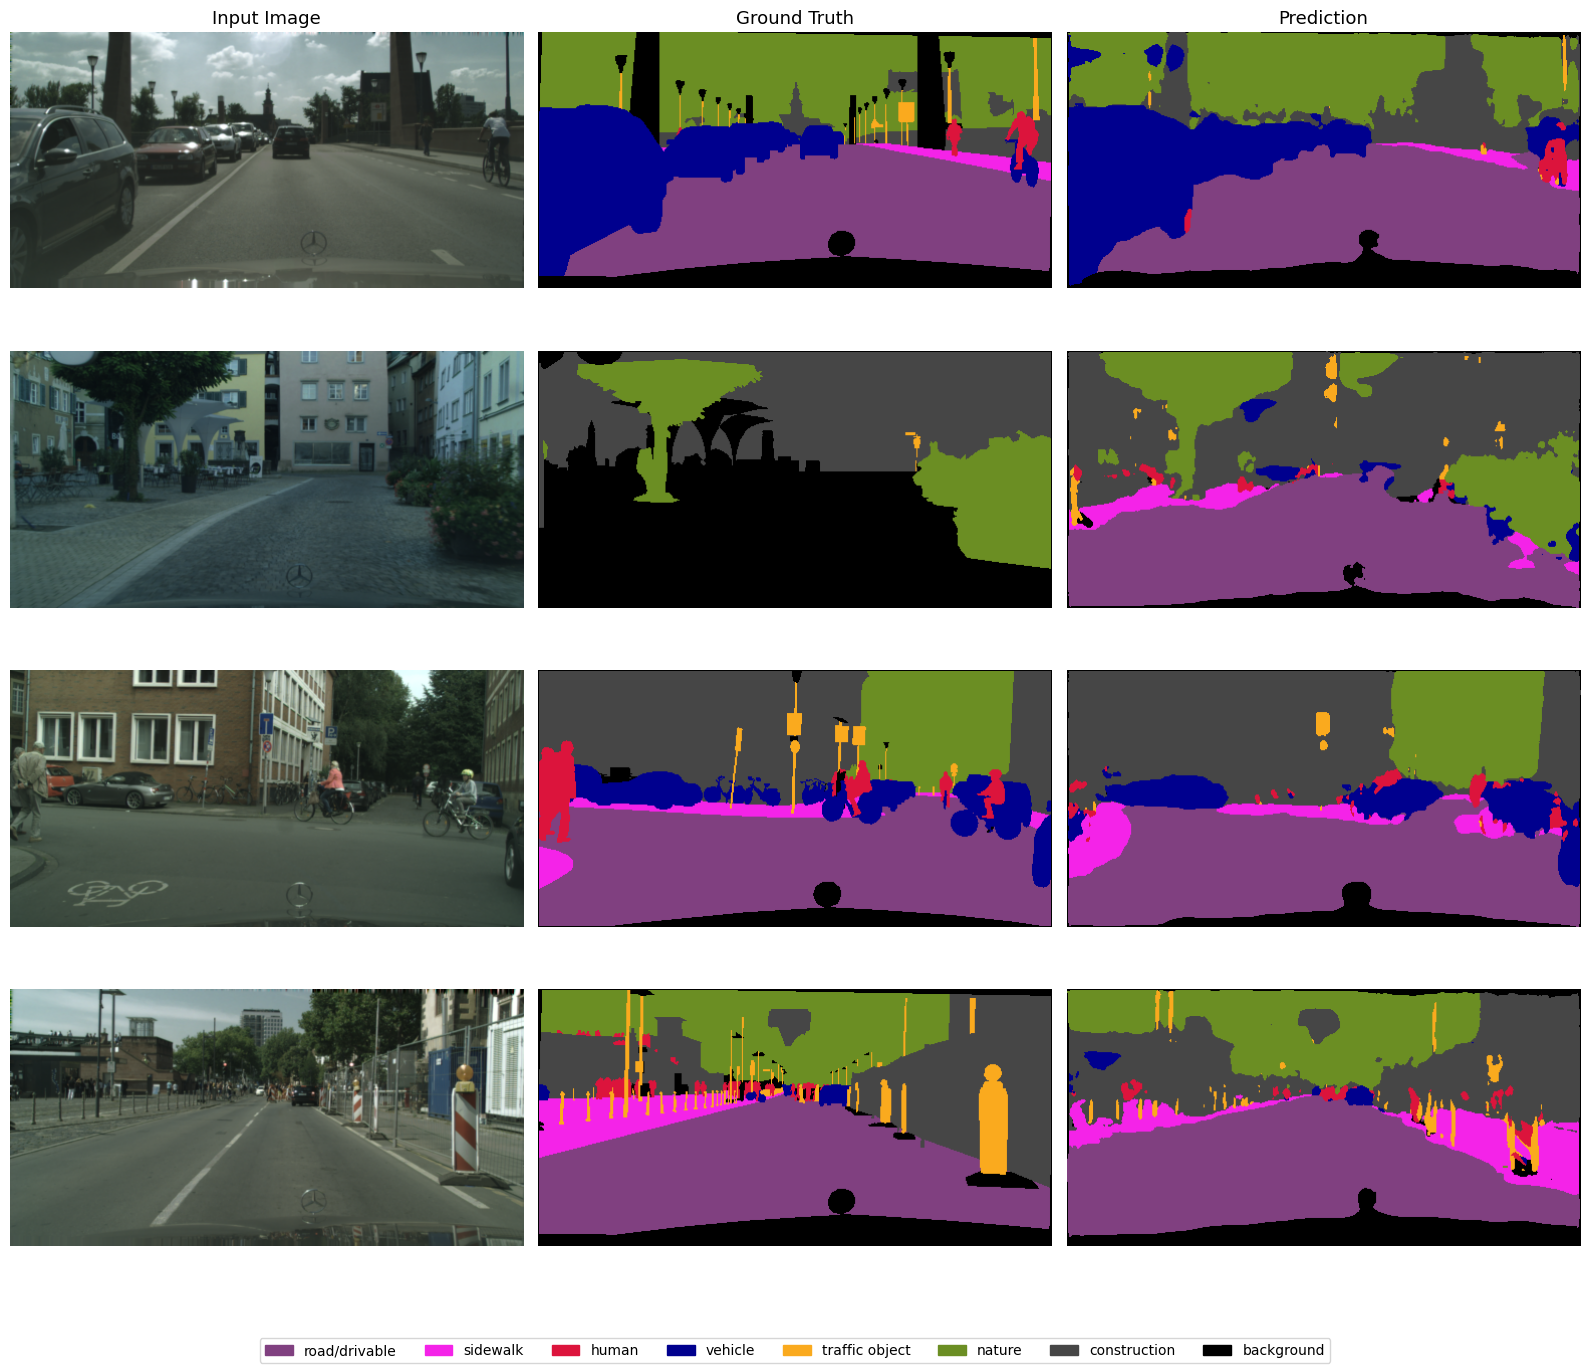

In [78]:
# ── Visualize predictions on validation set ──
model.eval()
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
col_titles = ["Input Image", "Ground Truth", "Prediction"]

for i in range(4):
    # random choose 4 images
    img, lbl, _ = val_ds[random.randint(0, len(val_ds) - 1)]
    # img, lbl, _ = val_ds[i]
    with torch.no_grad(), torch.amp.autocast("cuda"):
        pred = model(img.unsqueeze(0).to(device)).argmax(dim=1).squeeze(0).cpu().numpy()

    img_vis = inv_normalize(img).permute(1, 2, 0).clamp(0, 1).numpy()
    gt_vis = label_to_color(lbl.numpy())
    pred_vis = label_to_color(pred)

    axes[i, 0].imshow(img_vis)
    axes[i, 1].imshow(gt_vis)
    axes[i, 2].imshow(pred_vis)

    for j in range(3):
        axes[i, j].axis("off")
        if i == 0:
            axes[i, j].set_title(col_titles[j], fontsize=13)

patches = [
    mpatches.Patch(color=np.array(c) / 255, label=n) for c, n in zip(CLASS_COLORS, CLASS_NAMES)
]
fig.legend(handles=patches, loc="lower center", ncol=NUM_CLASSES, fontsize=10)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()